# XGBoost 하이퍼파라미터 및 주요 메서드 정리

XGBoost는 Gradient Boosting 알고리즘의 확장으로, 효율성과 성능이 뛰어난 머신러닝 라이브러리입니다. 이 문서에서는 주요 하이퍼파라미터와 메서드를 정리합니다.

---

## 1. 주요 하이퍼파라미터
XGBoost는 모델 학습에 영향을 주는 여러 하이퍼파라미터를 제공합니다. 아래는 중요한 하이퍼파라미터를 설명한 목록입니다.

### (1) 일반 파라미터
- **`booster`**:
  - 사용되는 부스터 타입.
  - 값: `gbtree` (기본값, 의사결정 트리 기반)_max_depth, subsample, colsample_bytree 등등, `gblinear` (선형 모델), `dart` (드롭아웃 트리 부스팅) 드롭아웃 방식을 GBT에 적용한 알고리즘, 무작위로 드랍아웃 과적합 방지, 모델 복잡도도 줄이고, 일반화도 개선할 수 있음.
  
- **`nthread`**:
  - 실행 시 사용할 스레드의 수.
  - 기본값은 시스템의 코어 개수.

- **`verbosity`**:
  - 로그 출력 수준.
  - 값: `0` (silent), `1` (warning), `2` (info), `3` (debug).

---

### (2) 부스터별 파라미터
#### gbtree와 dart 공통
- **`eta` (learning_rate)**:
  - 학습률로, 값이 작을수록 학습은 느리지만 더 정밀합니다.
  - 기본값: `0.3`.

- **`max_depth`**:
  - 트리의 최대 깊이.
  - 과적합 방지를 위해 조정.
  - 기본값: `6`.

- **`min_child_weight`**:
  - 리프 노드가 분할되기 위한 최소 가중치 합.
  - 과적합 방지 역할.

- **`subsample`**:
  - 학습에 사용하는 데이터 비율 (0.5~1).
  - 기본값: `1`.

- **`colsample_bytree`**:
  - 트리 수준에서 선택할 피처의 비율.
  - 기본값: `1`.

#### dart 추가 파라미터
- **`sample_type`**:
  - 드롭아웃 샘플링 방식.

- **`normalize_type`**:
  - 드롭된 노드의 기여를 정규화하는 방식.

---

### (3) 학습 목표 관련 파라미터
- **`objective`**:
  - 학습에 사용할 손실 함수.
  - 값: `reg:squarederror` (회귀), `binary:logistic` (이진 분류), `multi:softprob` (다중 클래스 확률).

- **`eval_metric`**:
  - 평가 지표.
  - 값: `rmse`, `logloss`, `error`, `auc` 등.

---

### (4) 과적합 방지 파라미터
- **`lambda`**:
  - L2 정규화 가중치.
  - 기본값: `1`.

- **`alpha`**:
  - L1 정규화 가중치.
  - 기본값: `0`.

- **`gamma`**:
  - 노드 분할 시 요구되는 최소 손실 감소값.
  - 값이 높을수록 분할이 어려워져 과적합 방지.

---

## 2. 주요 메서드
### (1) `fit()`
- 모델 학습 수행.
- 주요 인자:
  - `X`: 독립 변수.
  - `y`: 종속 변수.
  - `eval_set`: 검증 데이터.

---

### (2) `predict()`
- 학습된 모델로 예측 수행.

---

### (3) `score()`
- 기본 평가 지표로 모델 평가.

---

### (4) `plot_importance()`
- 피처 중요도를 시각화.
- 주요 인자:
  - `importance_type`: `weight`, `gain`, `cover`.

---

### (5) `cv()`
- 교차검증을 수행하며 성능 평가.

---

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

# 회귀 예제 데이터 생성
X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42)
data = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(X.shape[1])])
data['Target'] = y

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#XGBOOST 불러오기
#기본모델 학습

basic_model = xgb.XGBRegressor(random_state=111)
basic_model.fit(X_train, y_train)

## 기본모델 예측 및 평가
y_pred_basic = basic_model.predict(X_test)
rmse_basic = mean_squared_error(y_test, y_pred_basic, squared=False)
r2_basic = r2_score(y_test, y_pred_basic)

print(f'베이직모델 RMSE {rmse_basic}')
print(f'베이직모델 r2_basic {r2_basic}')

# 하이퍼 파라미터 튜닝
# GridSearchCV

param_grid ={
    'n_estimators' :[50,100,200],
    'learning_rate':[0.01,0.1,0.3],
    'max_depth':[3,5,7],
    'subsample':[0.7, 1.0],
    'colsample_bytree':[0.7,1.0]    
}

tuned_model = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=111),
    param_grid= param_grid,
    scoring= 'neg_root_mean_squared_error',
    cv = 3    
)

tuned_model.fit(X_train, y_train)
print(tuned_model.best_params_) # 최적의 하이퍼파라미터

## 튜닝된 모델의 예측값 성능
y_pred_tuned=tuned_model.best_estimator_.predict(X_test)
rmse_tuned = mean_squared_error(y_test, y_pred_tuned, squared=False)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f'튜닝모델 RMSE {rmse_tuned}')
print(f'튜닝모델 r2_basic {r2_tuned}')

D:\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


베이직모델 RMSE 41.34799507599749
베이직모델 r2_basic 0.8986637643384835
{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
튜닝모델 RMSE 23.236402759154522
튜닝모델 r2_basic 0.9679967822232032


D:\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


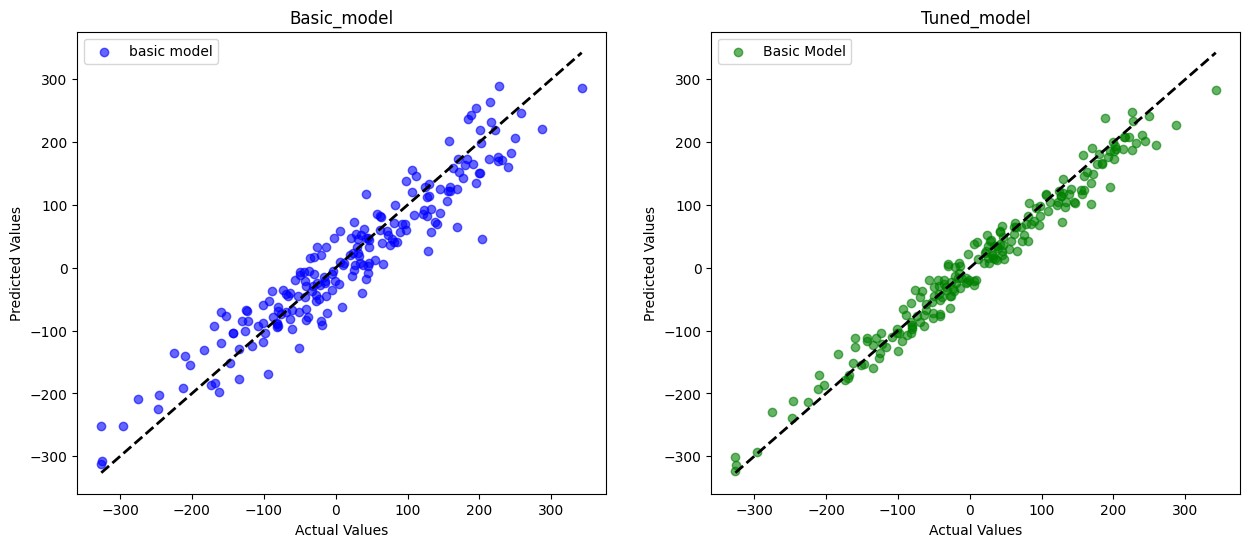

In [10]:
plt.figure(figsize=(15,6))
## 실제값과 기본모델값

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_basic, alpha=0.6, color='blue', label='basic model')
plt.plot([y_test.min(), y_test.max()],[y_test.min(),y_test.max()],'k--', lw=2)
plt.title('Basic_model')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
## 실제값과 튜닝된 모델 값

plt.subplot(1,2,2)
plt.scatter(y_test,y_pred_tuned, alpha=0.6, color= 'green',label='Basic Model')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'k--',lw=2)
plt.title('Tuned_model')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
## 실제값과 튜닝된 모델 값

## XGBoost 내에서도 피처 중요도
importances=tuned_model.best_estimator_.feature_importances_
feature = [f'Feature_{i}' for i in range(X.shape[1])]


<BarContainer object of 10 artists>

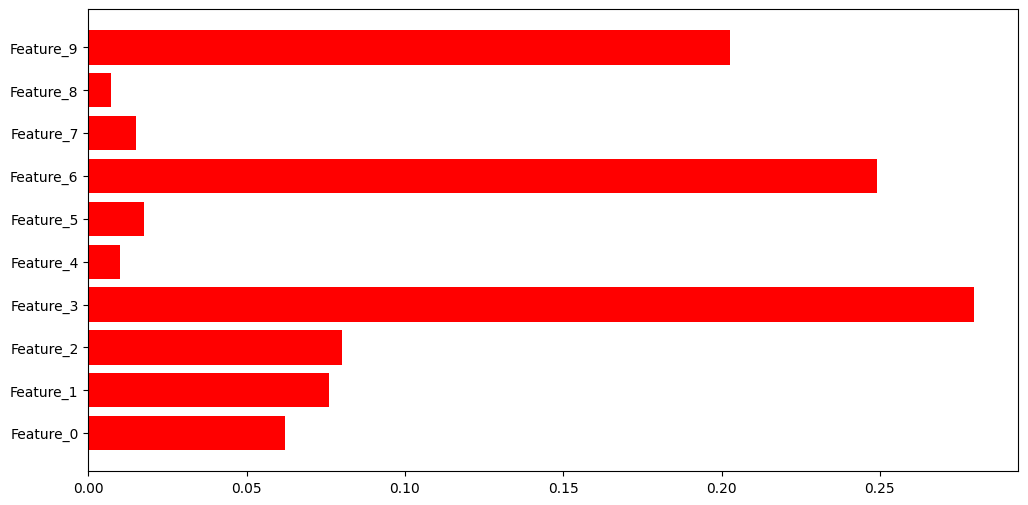

In [11]:
## 중요피처 시각화
## 피처에 대한 주요 시각화도 간단하게 추출할 수 있다.
importances=tuned_model.best_estimator_.feature_importances_
feature = [f'Feature_{i}' for i in range(X.shape[1])]
plt.figure(figsize=(12,6))
plt.barh(feature, importances, color='red')